# Tutorial: Methods for making plot boundaries with PlantCV-Geospatial

This tutorial uses PlantCV-Geospatial v1.0. This tutorial was last updated September 15, 2026. You must have PlantCV and PlantCV-Geospatial installed to use this tutorial. For installation instructions, visit [this page for PlantCV](https://docs.plantcv.org/en/stable/installation/) and [this page for PlantCV Geospatial](https://docs.plantcv.org/projects/geospatial/en/latest/installation/). 

Data used in this tutorial Example 2 is available from the following publicly available data: 

    Wilde, S. C. & Cope, D. A. Maize G2F UAV Data, College Station, TX 2019. CyVerse Data Commons https://doi.org/10.25739/D9GT-HV94 (2020).
  


This tutorial is an example workflow for making plot boundaries with different types of plots. This will cover basics of:
  - Reading in images with `plantcv-geospatial` (`gcv`)
  - Using the `field_layout` class in `gcv`
  - Image classes in `gcv`
  - Using the `InteractiveShapes` class to annotate your images


### All examples, Step 1: Load in packages and specify parameters

First, we load `plantcv.geospatial`. Here we also load the main `plantcv.plantcv.` package so that we can set our debug parameter and for checking our `outputs` class later.

In [1]:
from plantcv import geospatial as gcv
from plantcv import plantcv as pcv
pcv.params.debug = "plot"

# Check that PlantCV and PlantCV-Geospatial were loaded properly by checking the version
print(pcv.__version__)
print(gcv.__version__)

5.0.0rc3.dev11+g517f48ae5
0.1.dev1281+gb382d3b1f


`PlantCV` and all subpackages `pcv.params` to control debug behavior, text thickness, and other such variables that are used in many functions.

In `gcv` we add a similar [singleton class called `field_layout`](https://docs.plantcv.org/projects/geospatial/en/latest/Field_layout/) which you can use to keep several useful metrics about your particular field data. See the linked docs for a full list of attributes and for where they are used.

![Field Layout Terminology](img/row_plot_vocab.png)

## Example 1: Plot Boundaries when you have an existing shapefile. 

In this example, we have a file that specifies the layout of the field, perhaps from another software or from PlantCV-Geospatial, that we want to apply to this file. 

### Ex. 1, Step 2: Import (aka read) in an image. 
With our parameters set we are ready to read in an image.

`gcv.read` currently supports `.geotif` and select `.netcdf` files (as more accepted standards come out of the netcdf format we may expand to include more supported types there).

`gcv.read.geotif` is used here to read in a grayscale `.tif` file. There are four arguments to `read.geotif`:
- 1: 'filename': The path to a file
- 2: 'bands': Bands to read, defaults to "R,G,B" but supports R, G, B, RE, N, NIR, and GRAY.
- 3: 'cropto': Defaults to None but can be a path to a shapefile to crop the image to.
- 4: 'cutoff': Defaults to None but can be a percentile above which to remove points in grayscale images.

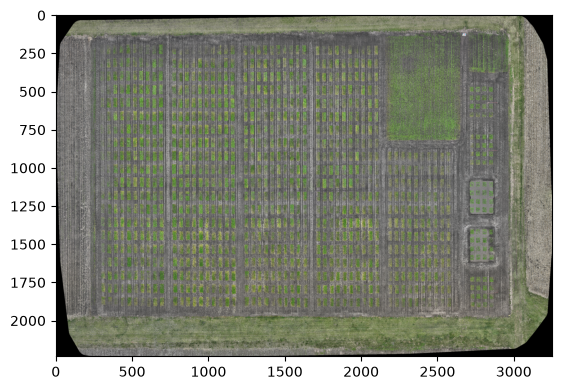

In [2]:
# Read GeoTIFF with PlantCV-Geospatial
img = gcv.read.geotif(
    filename="./img/South-Block-Color-Ortho-11-22-2024-orthophoto.tif", 
    bands="R,G,B"
    )

To keep track of important metadata when handling these images `gcv` includes two image classes, `GEO` and `DSM`.

`GEO` objects hold any multi-channel geospatial images and are a subclass of `numpy.ndarray` with special methods/attributes for a thumbnail (`thumb`), coordinate reference system (`crs`), transformations (`transfrom`), nodata values (`nodata`), wavelengths (`wavelengths`, which are numerical wavelength values found in the image metadata), and default wavelengths (`default_wavelengths`, which are a lookup table of defaults if a user inputs band names, such as NIR), and retrieving array slices from a wavelength (`get_wavelength(wavelength)`) as another `GEO` object.

### Ex. 1, Step 3: Load existing geojson files of field boundary and plot boundaries. 

These files may have been made with another software, or with PlantCV Geospatial and saved out previously. 

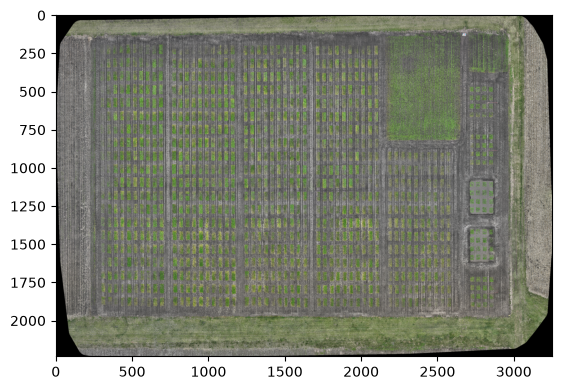

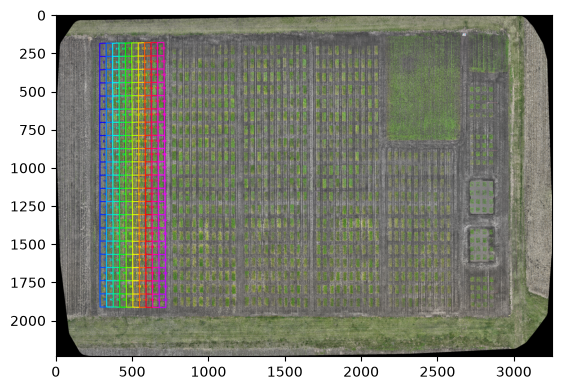

In [ ]:
# Use this to load in the plot map if it already exists.
plot_rois = gcv.convert.to_roi(
    img=img, 
    geojson="./shape_files/rgb_tutorial_plot_boundaries.geojson"
    )

Since this example has an existing, accurate boundary files, we will not adjust them. We will not save out any files, since we imported them instead. 

## Example 2: Non-interactive plot boundaries for precision-planted fields without a shapefile for field layouts. 

In this example, we know the number of ranges, columns, rows, and all of their spacing, but we do not have a shapefile for the field layout. This is useful when a precision planter is used and the specific spacing is known. 

### Ex. 2, Step 2: Import image

We will use the same image from Example 1, and are showing the import here again. See above for details. 

In [ ]:
# Read GeoTIFF with PlantCV-Geospatial
img = gcv.read.geotif(
    filename="./img/South-Block-Color-Ortho-11-22-2024-orthophoto.tif", 
    bands="R,G,B"
    )

### Ex. 2, Step 3: Specify plot spacing to create plot boundaries

Import a known field boundaries (aka field corners) shapefile, and specify the spacing to make individual plot boundaries. 

In [ ]:
# Use the auto_grid function to create a grid of individual plots. The parameters are set based on the field layout.

indiv_rows = gcv.create_shapes.auto_grid(img=img, field_corners_path="./shape_files/rgb_tutorial_close_crop.geojson", 
            out_path="./outputs/rgb_tutorial_auto_grid.geojson", num_ranges=20, num_columns=10,
            num_rows=7, range_spacing=1.42, range_length=2.95, row_length=0.17, column_spacing=0.99)


## Example 3: Interactive plot boundaries for precision-planted fields without a shapefile for field layouts. 

In this example, we know the number of ranges, columns, rows, and all of their spacing, but we do not have a shapefile for the field layout. Instead of doing this automatically like the previous example, we will do it interactively, which will allow us to make adjustments if needed. 

### Ex. 3, Step 2: Import image

See example 1 for details on the import function. 

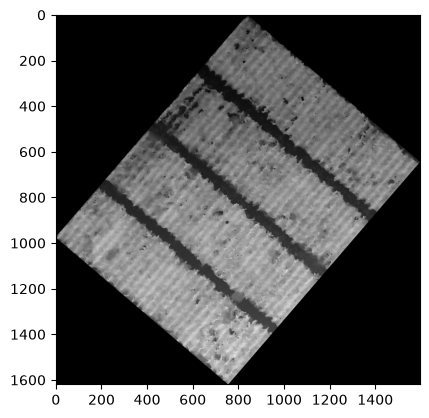

In [ ]:
#Here, we will title the imported image "dsm" because it is a digital surface model. 

dsm = gcv.read.geotif("img/cropped.tif", bands="gray")

### Ex. 3, Step 3: Define field layout parameters

We are using the same image as the previous example, but this time we have no shapefile outlining the plots. 

In [5]:
#Using the field layout of the data we are analyzing, we will specify the number of ranges, columns, and the spacing between them, as well as the range length and row length. 

gcv.field_layout.num_ranges = 4
gcv.field_layout.num_columns = 31
gcv.field_layout.range_spacing = 10
gcv.field_layout.range_length = 5
gcv.field_layout.row_length = 2

### Ex. 3, Step 4: Annotate field boundaries

The next feature of `gcv` that we'll look at is the `InteractiveShapes` class. This class works with a `napari` viewer to allow for annotation of important field coordinates.

This next cell opens a Napari window, where you can create layers. The call to `InteractiveShapes` will default to making a polygon layer called `field_boundary`, which is an important first step for our downstream analysis. In this particular case there is only one section of the field that we'll care about but often you will have to select your target area from a larger orthomosaic. 

Run the next cell, then draw the field boundary in the `field_boundary` layer in Napari.
In Napari, select `field_boundary` (it may already be selected), choose the polygon tool (the shape next to the rectangle icon), and draw the field outline by clicking vertices, then press enter. In order for the autogrid function to align properly, always start in the upper left corner of a field (not necessarily the upper left corner of the image) when drawing the boundary. 

The `InteractiveShapes` class has a `close()` method, but keep the viewer open for now to see what other functions do with it.

In [ ]:
# Open the Napari viewer to interactively draw the field boundary. 
# Leave the Napari viewer open. 

editor = gcv.create_shapes.InteractiveShapes(
    img=dsm,
    viewer_type="napari",
    field_layer="field_boundary",
    show=True
    )

The `InteractiveShapes` class has several helpful methods, the first of which is `to_shapes`. This lets us save a polygon/rectangle layer to a geojson file.

In [ ]:
#Save the polygon/rectangle layer of the field boundary as a geojson file named "vertices". 

vertices = editor.to_shapes(dest="./outputs/boundary_points-2.geojson", layername="field_boundary")

FileNotFoundError: [Errno 2] No such file or directory: './outputs/boundary_points.geojson'

### Ex. 3, Step 5: Define plots in the field based on spacing inputs. 

Next, since we defined traits of our field in the `field_layout` class we can call `grid` and `plots` to automatically cut our field into plots.
If you have a less perfect rectangle then you may need to use [other methods](https://docs.plantcv.org/projects/geospatial/en/latest/shapes_grid_from_coords/) to label your plots.

In [ ]:
# Return to the Napari viewer to add the grid and plots to the field, which will be populated based on the parameters set at the beginning of this tutorial. 

editor.grid()
editor.plots()

### Ex. 3, Step 6: Save layer as another geojson file.

In [ ]:
#Save the polygon/rectangle layer of the plot boundaries as the geojson file named "vertices" that already contains the field boundaries. 

vertices = editor.to_shapes(dest="./outputs/plots-2.geojson", layername="Plots")

#Now you can close the napari viewer. 

## Example 4: Irregularly planted plots or individual plants

This example covers a field of individually planted plants. They were not planted in straight rows or regular spacing. This method is suitable for plants or plots. We know the number of rows and columns, but they are irregularly spaced. 

### Ex. 4, Step 2: Import (aka read) in an image. 

See Example 1 for details on the import function. 

In [ ]:
# Read in image

img = gcv.read.geotif(filename="./img/Flowering_tutorial_cropped.tif", bands="b,g,r,re,nir,mask")

### Ex. 4, Step 3: Create the field boundary

Create the boundary using the autogrid method on an InteractiveShapes Object. Use different methods in [*gcv.create_shapes.InteractiveShapes*](https://docs.plantcv.org/projects/geospatial/en/latest/InteractiveShapes/) to set up the boundaries in the image. Using the `Add Polygon` tool (highlighted in the image below), draw a tight rectangle around the edges of the entire field, starting in the upper left corner, in the `field_boundary` layer once the napari window opens. Once you have selected the 4 points for your rectangle, press the `Enter` key to finalize the polygon.

In [ ]:
# Load the napari viewer to add the field boundary layer

editor = gcv.create_shapes.InteractiveShapes(img, field_layer="field_boundary")

# Click "enter" when complete. Keep the napari viewer open. 

### Ex. 4, Step 4: Create plant/plot boundaries with autogrid method
Once the rectangle is drawn around the field in the `field_boundary` layer, automatically draw a grid of lines to outline individual plots using the `grid` method. Adjust **[columns, ranges]** in `numdivs` if they are off until plots are covered. See example image of the napari viewer. 

Use `field_layout` when spacing is known precisely for plots, such as example 3. Use `numdivs` when you just know the plot count but not the spacing, or when the spacing needs significant adjustments, such as in this example. 

In [ ]:
# Load the napari viewer to add the field boundary layer and set the grid to 11 columns and 6 ranges. 
# This field was planted with 11 columns and 6 ranges. Each plant is considered an individual plot in this example. 

editor.grid(numdivs=[11,6])

# Click "enter" when complete. Keep the napari viewer open. 

### Ex. 4, Step 5: Adjust the plant/plot boundaries
Adjust the gridlines using the `Select vertices` tool in napari (see image below) to more precisely have plot boundaries. This is a particularly important tool in cases where fields were not planted in straight grids. After adjusting the gridlines, draw polygons using the line intersections using the `plots` method.

In [ ]:
# Load the napari viewer to add the field boundary layer and correct the lines until they enclose individual plots. Draw polygons using the line intersections. You can edit the polygon vertices if they are still not perfect.

editor.plots()

# Click "enter" when complete. Keep the napari viewer open. 

### Ex. 4, Step 6: Save plot boundaries to a file

After boundaries have been adjusted, save them to a file. 

In [ ]:
# Save the plot boundaries to a file

plots = editor.to_shapes(dest="./outputs/plots-ex3.geojson", layername="Plots")

# You may now close the napari viewer. 

We hope that this is a useful getting started guide for plot boundaries in `PlantCV-Geospatial`.

For details about functions please see the [online documentation](https://docs.plantcv.org/projects/geospatial/en/latest/).

For questions about the docs, bug reports, feature requests, and other issues please open a [github issue](https://github.com/danforthcenter/plantcv-geospatial/issues) and our team will try to help!